## Utils

In [68]:
def prepend_zeros(example, num_metadata_tokens=6):
    # Convert tensor to list for manipulation
    import torch

    expressions = example["expressions"].tolist()
    zeros = [0.0] * num_metadata_tokens
    expressions = zeros + expressions

    # Convert back to tensor if you're using HF with torch format
    example["expressions"] = torch.tensor(expressions, dtype=torch.float)
    return example

def move_cls_to_front(example, cls_token_id=60695):
    genes = example["genes"].tolist()
    
    import torch

    if cls_token_id in genes:
        genes.remove(cls_token_id)
        genes = [cls_token_id] + genes

    example["genes"] = torch.tensor(genes, dtype=torch.long)
    return example

def compute_pca_embeddings(
    adata,
    n_components=50,
    latent_key="X_pca",
    normalize=True,
    log1p=True,
    scale=True,
    zero_center=True,
    svd_solver=None,
    random_state=0,
):
    """
    Compute PCA embeddings on AnnData and store them in adata.obsm[latent_key].

    Parameters:
    - adata: AnnData object (must contain data in adata.X or specified layer).
    - layer: Layer name to use for PCA (default: None → adata.X).
    - n_components: Number of principal components to compute.
    - latent_key: Key under adata.obsm to store PCA output.
    - normalize: If True, normalize per cell (scanpy.pp.normalize_total).
    - log1p: If True, apply log1p transformation.
    - scale: If True, scale data (zero-mean, unit variance).
    - zero_center: Passed to scanpy.pp.pca; if True, center variables (regular PCA), else applies SVD.
    - svd_solver: Optional solver choice for PCA (default: None → auto).
    - random_state: Random seed for reproducibility.

    Returns:
    - Updated AnnData object with PCA embeddings stored in adata.obsm[latent_key].
    """
    import scanpy as sc

    # Work on a copy to avoid modifying adata.X in place
    adata_copy = adata.copy()

    # Normalize, log-transform, and scale as requested
    if normalize:
        sc.pp.normalize_total(adata_copy)
    if log1p:
        sc.pp.log1p(adata_copy)
    if scale:
        sc.pp.scale(adata_copy)

    # Compute PCA using the specified data source (adata.X or the layer)
    sc.pp.pca(
        adata_copy,
        n_comps=n_components,
        zero_center=zero_center,
        svd_solver=svd_solver,
        random_state=random_state,
    )

    # Store the result in the original AnnData object's obsm
    adata.obsm[latent_key] = adata_copy.obsm["X_pca"][:, :n_components]

    return adata

def compute_scvi_embeddings(
    adata,
    batch_key="dataset_id",
    n_layers=2,
    n_latent=50,
    gene_likelihood="nb"
):
    """
    Compute and store scVI latent embeddings in adata.obsm["X_scvi"],
    assuming raw counts are in adata.X.

    Parameters:
    - adata: AnnData object with raw count data in adata.X.
    - batch_key: Key in adata.obs indicating batch labels (default: "dataset_id").
    - n_layers: Number of hidden layers in encoder/decoder.
    - n_latent: Dimensionality of the latent space.
    - gene_likelihood: Likelihood model to use ("nb", "zinb", etc.).

    Returns:
    - Updated AnnData object with latent embeddings in .obsm["X_scvi"].
    """
    import scvi

    scvi.model.SCVI.setup_anndata(adata, batch_key=batch_key)
    model = scvi.model.SCVI(
        adata,
        n_layers=n_layers,
        n_latent=n_latent,
        gene_likelihood=gene_likelihood
    )
    model.train()
    adata.obsm["X_scvi"] = model.get_latent_representation()
    return adata

def compute_scgpt_embeddings(
    data_path: str,
    model_dir: str,
    gene_col: str = "feature_name",
    batch_size: int = 128,
    return_new_adata: bool = False,
    save_path: str = None
):
    """
    Computes SCGPT embeddings for a given h5ad file.

    Parameters:
        data_path (str): Path to the input .h5ad file.
        model_dir (str): Path to the pretrained SCGPT model directory.
        gene_col (str): Column name for gene features.
        batch_size (int): Batch size to use for embedding.
        return_new_adata (bool): Whether to return a new AnnData object.

    Returns:
        AnnData: The embedded AnnData object (modified in-place if return_new_adata=False).
    """

    from scgpt.tasks import embed_data
    import scanpy as sc
    adata = sc.read_h5ad(data_path)
    adata = embed_data(
        adata_or_file=adata,
        model_dir=model_dir,
        gene_col=gene_col,
        batch_size=batch_size,
        return_new_adata=return_new_adata,
    )
    if save_path:
        adata.write(save_path)
        print(f"Embedded data saved to {save_path}")
    return adata

def compute_umap_and_leiden(adata, use_rep="custom", umap_key="custom", leiden_key="custom", metric="euclidean", n_neighbors=15, min_dist=0.3, random_state=0, resolution=1.0):
    """
    Compute neighbors and UMAP for a given embedding and store in adata.obsm[umap_key].

    Parameters:
    - adata: AnnData object with embeddings in adata.obsm[use_rep].
    - use_rep: Key in adata.obsm to use as input for computing neighbors.
    - umap_key: Key in adata.obsm to store UMAP coordinates.
    - n_neighbors: Number of neighbors for the KNN graph (default: 15).
    - min_dist: Controls how tightly UMAP packs points together (default: 0.3).
    - random_state: Random seed for reproducibility.

    Returns:
    - Updated AnnData object with UMAP stored in adata.obsm[umap_key].
    """
    import scanpy as sc

    # Compute neighbors from the specified representation
    sc.pp.neighbors(adata, use_rep=f"X_{use_rep}", n_neighbors=n_neighbors, metric=metric, random_state=0)

    # Compute UMAP
    sc.tl.umap(adata, min_dist=min_dist, random_state=random_state)

    # Save UMAP to a custom key to avoid overwriting
    adata.obsm[f"X_umap_{umap_key}"] = adata.obsm["X_umap"]

    # Run Leiden clustering
    sc.tl.leiden(
        adata,
        key_added=f"leiden_{leiden_key}",
        resolution=resolution,
    )

    return adata

def compute_clustering_metrics(adata, embedding_key='X_umap', cluster_key='leiden', label_key='cell_type'):
    """
    Compute Silhouette Score, ARI, and NMI for a given AnnData object.
    
    Parameters:
        adata (AnnData): Annotated data object with embedding and clustering.
        embedding_key (str): Key in adata.obsm for the 2D embedding (e.g., UMAP).
        cluster_key (str): Key in adata.obs for clustering labels (e.g., leiden).
        label_key (str): Key in adata.obs for ground truth labels (e.g., cell type).
        
    Returns:
        dict: Dictionary with silhouette, ARI, and NMI scores.
    """
    from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

    embedding = adata.obsm[f"X_{embedding_key}"]
    cluster_labels = adata.obs[f"leiden_{cluster_key}"].values
    true_labels = adata.obs[label_key].values

    # Silhouette Score: only makes sense if more than 1 cluster
    if len(set(cluster_labels)) > 1:
        sil_score = silhouette_score(embedding, cluster_labels)
    else:
        sil_score = float('nan')

    ari = adjusted_rand_score(true_labels, cluster_labels)
    nmi = normalized_mutual_info_score(true_labels, cluster_labels)

    return {
        'silhouette': sil_score,
        'ARI': ari,
        'NMI': nmi
    }

## scImmune - Embedding Generation

In [54]:
import numpy as np
import pandas as pd
import scanpy as sc
import torch
from torch.utils.data import DataLoader
import tqdm

# --- your modules ---
from tokenizer import ScImmuneTokenizer
from config import ScImmuneConfig
from model import ScImmuneModel
from collator import ScImmuneDataCollator

# =======================
# User settings
# =======================
H5AD_PATH = "../data/inference/influenzaPBMC.h5ad"
MODEL_DIR = "final"     # folder with model.safetensors + config.json
VOCAB_FILE = "vocab_with_metadata.json"
NUM_META = 6
SCALE_FACTOR = 100.0                        # must match training
BATCH_SIZE = 128
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Map obs fields -> token tag used in your vocab
# (Adjust the right-hand side strings so they exactly match your vocab’s token prefixes)

FIELD_TO_TAG = {
    "cell_type_ontology_term_id":           "cell_type",
    "self_reported_ethnicity_ontology_term_id": "self_reported_ethnicity",
    "tissue_general_ontology_term_id":      "tissue_general",
    "development_stage_ontology_term_id":   "development_stage",
    "sex_ontology_term_id":                 "sex",
    "disease_ontology_term_id":             "disease",
}
assert len(FIELD_TO_TAG) == NUM_META, "NUM_META must match the number of metadata fields."

# =======================
# Load data & model
# =======================
adata = sc.read_h5ad(H5AD_PATH)

for colname in list(adata.obs.columns):
    if pd.api.types.is_categorical_dtype(adata.obs[colname]):
        adata.obs[colname] = adata.obs[colname].cat.remove_unused_categories()

/tmp/ipykernel_1671665/1476838484.py:44: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs[colname]):


In [55]:
adata.obs["disease_ontology_term_id"] = adata.obs["disease_ontology_term_id"].astype(str)
adata.obs.loc[adata.obs["disease"] == "normal", "disease_ontology_term_id"] = "DOID:4"

In [56]:
X = adata.X.toarray() if not isinstance(adata.X, np.ndarray) else np.asarray(adata.X)
gene_symbols = np.asarray(adata.var.feature_name)

gene_symbols

array(['LINC01409', 'NOC2L', 'PERM1', ..., 'LGALS17A', 'FLJ43315', 'XGY2'],
      dtype=object)

In [57]:
tok = ScImmuneTokenizer(vocab_file=VOCAB_FILE)
cfg = ScImmuneConfig.from_pretrained(MODEL_DIR)
model = ScImmuneModel.from_pretrained(MODEL_DIR, config=cfg).to(DEVICE).eval()

cls_id = tok.convert_tokens_to_ids(tok.cls_token)
unk_token = tok.unk_token
unk_id = tok.convert_tokens_to_ids(unk_token)

In [58]:
import tqdm
metadata_fields = [
                    "cell_type_ontology_term_id",
                    "self_reported_ethnicity_ontology_term_id", 
                    "tissue_general_ontology_term_id",
                    "development_stage_ontology_term_id",
                    "sex_ontology_term_id",
                    "disease_ontology_term_id"
]

gene_names = adata.var.feature_name.values # get gene names

tokenized_input_ids = []
tokenized_values = []

for i in range(adata.n_obs):
    
    # 1. Get dense expression vector
    row = adata.X[i]
    if not isinstance(row, np.ndarray):
        row = row.toarray().squeeze()

    # 2. Get metadata tokens
    obs_row = adata.obs.iloc[i]
    metadata_tokens = []
    for field in metadata_fields:
        val = obs_row.get(field)
        if isinstance(val, str) and val != "NA" and "=" not in val:
            if field == "tissue_ontology_term_id":
                token = f"<{field.split('_ontology_term_id')[0]}_general={val}>"
            else:
                token = f"<{field.split('_ontology_term_id')[0]}={val}>"
            metadata_tokens.append(token)

    # 3. Tokenize
    tokenized = tok.tokenize_cell_batch(
        data=np.expand_dims(row, axis=0),
        gene_ids=gene_names,
        metadata_tokens=metadata_tokens,
        append_cls=True,
        include_zero_gene=False
    )
    
    input_ids, values = tokenized[0]
    tokenized_input_ids.append(input_ids)
    tokenized_values.append(values)

In [59]:
from datasets import Dataset

# Padding and truncation happen in DataCollator, not here
hf_dataset = Dataset.from_dict({
    "genes": tokenized_input_ids,
    "expressions": tokenized_values
})

hf_dataset.set_format(type="torch", columns=["genes", "expressions"])

In [60]:
hf_dataset = hf_dataset.map(prepend_zeros)
hf_dataset = hf_dataset.map(move_cls_to_front)

Map: 100%|██████████| 29752/29752 [00:12<00:00, 2462.12 examples/s]


In [63]:
hf_dataset["genes"][0][:10]

tensor([60695, 60697, 60697, 60697, 60697, 60697, 60697, 12241, 34797,  2921])

In [ ]:
import torch

hf_dataset = hf_dataset.map(
    lambda example: {
        'genes': (
            lambda g: g[:1] + [60697]*6 + g[7:] # replace all metadata tokens with <unk> value
        )(example['genes'].tolist())
    }
)

Map: 100%|██████████| 29752/29752 [00:13<00:00, 2169.24 examples/s]


In [64]:
import torch.nn.functional as F

# =======================
# Collator for PCPT inference
# =======================
# We already scaled values; we just need padding + attention_mask.
collator = ScImmuneDataCollator(
    do_padding=True,
    pad_token_id=tok.pad_token_id,
    pad_value=-2,
    do_mlm=False,
    do_binning=False,
    mlm_probability=0.0,
    max_length=getattr(cfg, "max_seq_len", 2000),
    sampling=False,
    keep_first_n_tokens= 1 + NUM_META,
    data_style="pcpt",
    scale_factor=100.0,
)
# # If your collator tries to scale on pcpt, disable:
# setattr(collator, "scale_factor")

dl = DataLoader(hf_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collator)

# =======================
# Embed
# =======================
embs = []
with torch.no_grad():
    for batch in dl:
        # collator._call_pcpt likely returns {"gene","expr"} in your codebase.
        # If you already patched it to return ("input_ids","values","attention_mask"), adapt here.
        input_ids = batch.get("input_ids", batch.get("gene")).to(DEVICE)
        values    = batch.get("values",    batch.get("expr")).to(DEVICE)

        # HF attention mask: 1=keep, 0=pad
        attention_mask = (input_ids != tok.pad_token_id).long().to(DEVICE)

        out = model(
            input_ids=input_ids,
            values=values,
            attention_mask=attention_mask,
            generative_training=False,  # force perceptual path
        )
        embs.append(out["cell_emb"].detach().cpu())

embs = torch.cat(embs, dim=0)  # shape: (n_cells, d)

# # L2-normalize per cell
embs = F.normalize(embs, p=2, dim=1)  # keeps magnitude=1

adata.obsm["X_scimmune"] = embs.numpy()

In [13]:
compute_pca_embeddings(adata)

AnnData object with n_obs × n_vars = 70000 × 40568
    obs: 'soma_joinid', 'dataset_id', 'assay', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'tissue', 'tissue_ontology_term_id', 'tissue_general', 'tissue_general_ontology_term_id'
    var: 'soma_joinid', 'feature_id', 'feature_name', 'feature_type', 'feature_length', 'nnz', 'n_measured_obs', 'id_in_vocab'
    obsm: 'X_scGPT', 'X_scimmune', 'X_pca'

In [14]:
compute_scvi_embeddings(adata, batch_key=None)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Trainer will use only 1 of 3 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=3)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A30') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]
/home/s5srinivasan/immune-foundational-model/.venv/lib64/python3.9/site-packages/lightning/pytor

Epoch 114/114: 100%|██████████| 114/114 [12:02<00:00,  6.34s/it, v_num=1, train_loss_step=5.6e+3, train_loss_epoch=4.56e+3] 

`Trainer.fit` stopped: `max_epochs=114` reached.


Epoch 114/114: 100%|██████████| 114/114 [12:02<00:00,  6.33s/it, v_num=1, train_loss_step=5.6e+3, train_loss_epoch=4.56e+3]


AnnData object with n_obs × n_vars = 70000 × 40568
    obs: 'soma_joinid', 'dataset_id', 'assay', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'tissue', 'tissue_ontology_term_id', 'tissue_general', 'tissue_general_ontology_term_id', '_scvi_batch', '_scvi_labels'
    var: 'soma_joinid', 'feature_id', 'feature_name', 'feature_type', 'feature_length', 'nnz', 'n_measured_obs', 'id_in_vocab'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_scGPT', 'X_scimmune', 'X_pca', 'X_scvi'

In [15]:
adata.obsm["X_scgpt"] = adata.obsm["X_scGPT"]

In [65]:
# compute_umap_and_leiden(adata, use_rep="pca", umap_key="pca", leiden_key="pca")
# compute_umap_and_leiden(adata, use_rep="scvi", umap_key="scvi", leiden_key="scvi")
# compute_umap_and_leiden(adata, use_rep="scgpt", umap_key="scgpt", leiden_key="scgpt")
compute_umap_and_leiden(adata, use_rep="scimmune", umap_key="scimmune", leiden_key="scimmune")

AnnData object with n_obs × n_vars = 29752 × 40568
    obs: 'soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars', '_scvi_batch', '_scvi_labels', 'leiden_scgpt', 'leiden_scimmune', 'leiden_scvi', 'leiden_pca'
    var: 'soma_joinid', 'feature_id', 'feature_name', 'feature_type', 'feature_length', 'nnz', 'n_measured_obs', 'id_in_vocab'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'leiden_pca', 'leiden_scgpt', 'leiden_scimmune', 'leiden_scvi', 'neighbors', 'umap'
    obsm: 'X_

In [66]:
methods = ["pca","scvi","scgpt", "scimmune"]

for id in methods:
    print(id, compute_clustering_metrics(adata, embedding_key=id, cluster_key=id, label_key='cell_type'))

pca {'silhouette': 0.18483858, 'ARI': 0.22103614293645127, 'NMI': 0.5493194498704279}
scvi {'silhouette': 0.103999674, 'ARI': 0.21345922103967377, 'NMI': 0.5334445981490733}
scgpt {'silhouette': 0.15393326, 'ARI': 0.2560721331015635, 'NMI': 0.5804410414053224}
scimmune {'silhouette': 0.11079169, 'ARI': 0.2086536571589644, 'NMI': 0.5099478941106795}


In [33]:
adata.obs.cell_type.unique()

['unknown', 'B cell', 'platelet', 'CD8-positive, alpha-beta T cell', 'classical monocyte', ..., 'plasmablast', 'lung macrophage', 'CD4-positive, alpha-beta T cell', 'mature alpha-beta T cell', 'CD14-positive, CD16-negative classical monocyte']
Length: 12
Categories (12, object): ['B cell', 'CD14-positive, CD16-negative classical monocyte', 'CD4-positive, alpha-beta T cell', 'CD8-positive, alpha-beta T cell', ..., 'non-classical monocyte', 'plasmablast', 'platelet', 'unknown']

In [28]:
import numpy as np

# Compute counts per cell type
cell_type_counts = adata.obs["cell_type"].value_counts()

# Keep only those with count > 1000
valid_cell_types = cell_type_counts[cell_type_counts > 1000].index

# Filter AnnData
adata = adata[adata.obs["cell_type"].isin(valid_cell_types)].copy()

print(f"Remaining cell types: {len(valid_cell_types)}")
print(adata.obs["cell_type"].value_counts())

Remaining cell types: 12
cell_type
classical monocyte                                 10405
CD4-positive, alpha-beta T cell                     9670
CD8-positive, alpha-beta T cell                     7774
unknown                                             6672
B cell                                              5849
natural killer cell                                 5163
lung macrophage                                     2325
platelet                                            1920
non-classical monocyte                              1529
plasmablast                                         1099
CD14-positive, CD16-negative classical monocyte     1070
mature alpha-beta T cell                            1033
Name: count, dtype: int64


In [ ]:
adata.obsm.

AnnData object with n_obs × n_vars = 54509 × 40568
    obs: 'soma_joinid', 'dataset_id', 'assay', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'tissue', 'tissue_ontology_term_id', 'tissue_general', 'tissue_general_ontology_term_id', '_scvi_batch', '_scvi_labels', 'leiden_pca', 'leiden_scvi', 'leiden_scgpt', 'leiden_scimmune'
    var: 'soma_joinid', 'feature_id', 'feature_name', 'feature_type', 'feature_length', 'nnz', 'n_measured_obs', 'id_in_vocab'
    uns: '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'leiden_pca', 'leiden_scvi', 'leiden_scgpt', 'leiden_scimmune', 'cell_type_colors'
    obsm: 'X_scGPT', 'X_scimmune', 'X_pca', 'X_scvi', 'X_scgpt', 'X_umap', 'X_umap_pca', 'X_umap_scvi', 'X_umap_scgpt', 'X_umap_scimmune'
    obsp: 'distances', 'con

In [ ]:
X = np.asarray(adata.obsm[], dtype=np.float32)

[[-2.78650038e-02  5.08529774e-05  1.49382018e-02 ...  1.03240961e-03
   1.85944308e-02  3.28387730e-02]
 [-2.21530516e-02 -1.76151302e-02  2.76448298e-02 ...  8.45072791e-03
   1.04730413e-03  4.15681563e-02]
 [-1.49784805e-02 -1.43712899e-03  1.63269211e-02 ... -5.70114190e-03
   2.12390106e-02  4.90894206e-02]
 ...
 [-5.15343696e-02  3.27366889e-02 -1.59021765e-02 ... -5.70001192e-02
  -8.53368454e-03  2.79362258e-02]
 [-1.43975345e-02  1.94967277e-02  5.20137697e-03 ... -4.16753255e-02
   5.37721207e-03  4.84704524e-02]
 [-3.27025391e-02  3.92153300e-03  8.72807484e-03 ... -5.83681185e-03
  -3.28830592e-02  3.42516340e-02]]


In [35]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# ==== config ====
LABEL_COL = "cell_type"        # change if needed
REP_KEY   = "X_scgpt"       # e.g., "X_scimmune", "X_scgpt", "X_scvi", "X_pca"
TEST_SIZE = 0.20
RANDOM_SEED = 0

# ==== 1) pull embeddings + labels ====
X = np.asarray(adata.obsm[REP_KEY], dtype=np.float32)
labels = adata.obs[LABEL_COL].astype("category")

# drop cells with missing labels (just in case)
keep = ~labels.isna().values
X = X[keep]
labels = labels[keep]

y = labels.cat.codes.values
class_names = list(labels.cat.categories)

# sanity
assert X.shape[0] == y.shape[0] and X.ndim == 2, f"X shape {X.shape}, y shape {y.shape}"

# ==== 2) split (stratified) ====
Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)

# ==== 3) build a simple pipeline: Standardize -> Logistic Regression ====
# Standardizing helps the linear classifier (even if X is L2‑normalized already).
clf = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("logreg", LogisticRegression(
        penalty="l2",
        C=4.0,                 # tune if under/over-regularized
        max_iter=2000,
        n_jobs=-1,
        class_weight="balanced",  # good default if label distribution is skewed
        solver="lbfgs",
        multi_class="multinomial",  # proper softmax for multi-class
        verbose=0,
    )),
])

# ==== 4) train ====
clf.fit(Xtr, ytr)

# ==== 5) evaluate ====
yp = clf.predict(Xte)

print("== Linear probe (Logistic Regression) on", REP_KEY, "==")
print("Accuracy:", accuracy_score(yte, yp))
print("Macro‑F1:", f1_score(yte, yp, average="macro"))
print("\nClassification report:")
print(classification_report(yte, yp, target_names=class_names, digits=3))

cm = confusion_matrix(yte, yp)
print("\nConfusion matrix shape:", cm.shape)

/home/s5srinivasan/immune-foundational-model/.venv/lib64/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


== Linear probe (Logistic Regression) on X_scgpt ==
Accuracy: 0.9504678040726472
Macro‑F1: 0.9442431353164279

Classification report:
                                                 precision    recall  f1-score   support

                                         B cell      0.997     0.997     0.997      1170
CD14-positive, CD16-negative classical monocyte      0.977     0.972     0.974       214
                CD4-positive, alpha-beta T cell      0.958     0.953     0.956      1934
                CD8-positive, alpha-beta T cell      0.920     0.878     0.898      1555
                             classical monocyte      0.986     0.965     0.975      2081
                                lung macrophage      0.944     0.948     0.946       465
                       mature alpha-beta T cell      0.772     0.937     0.846       206
                            natural killer cell      0.928     0.955     0.941      1033
                         non-classical monocyte      0.818     0

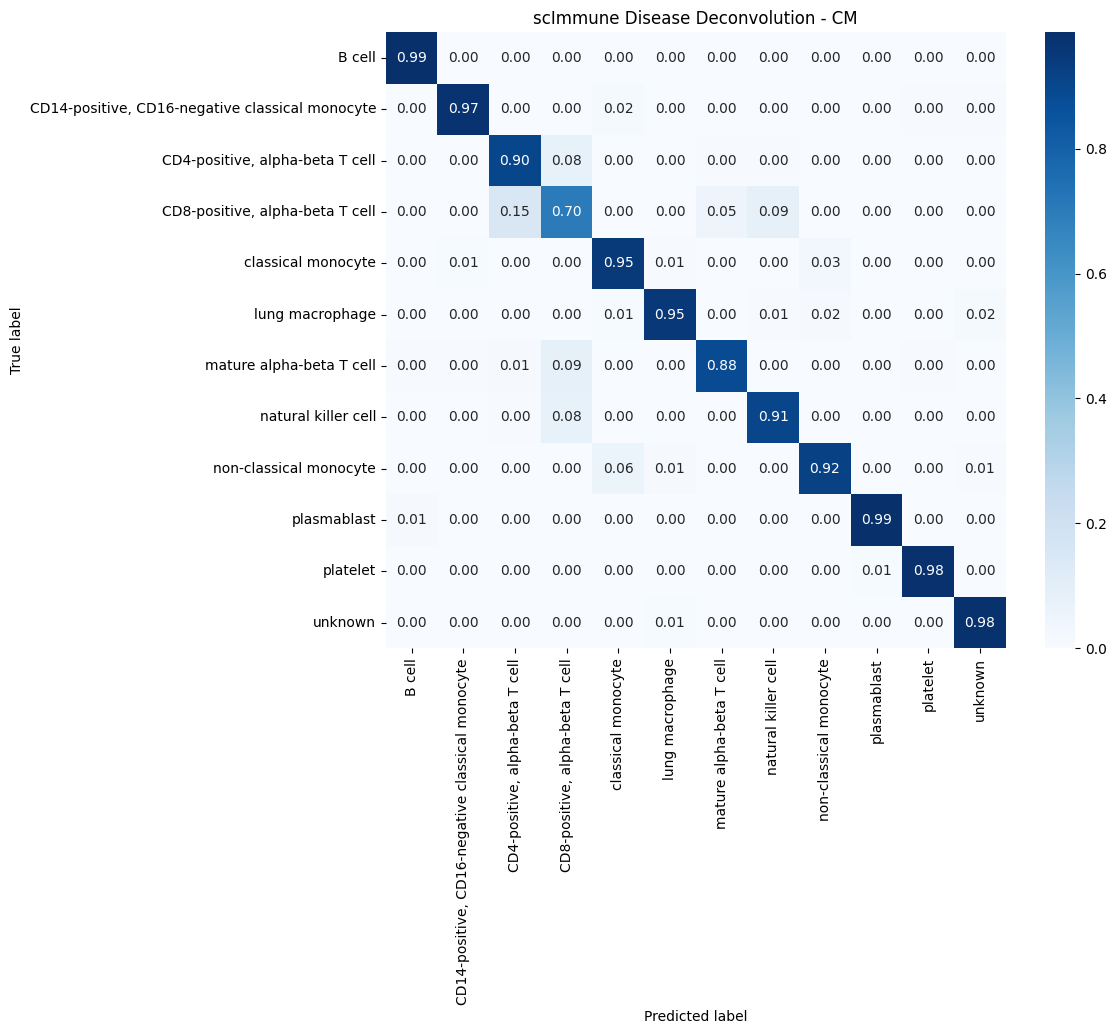

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(yte, yp, normalize='true')

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("scImmune Disease Deconvolution - CM")
plt.show()

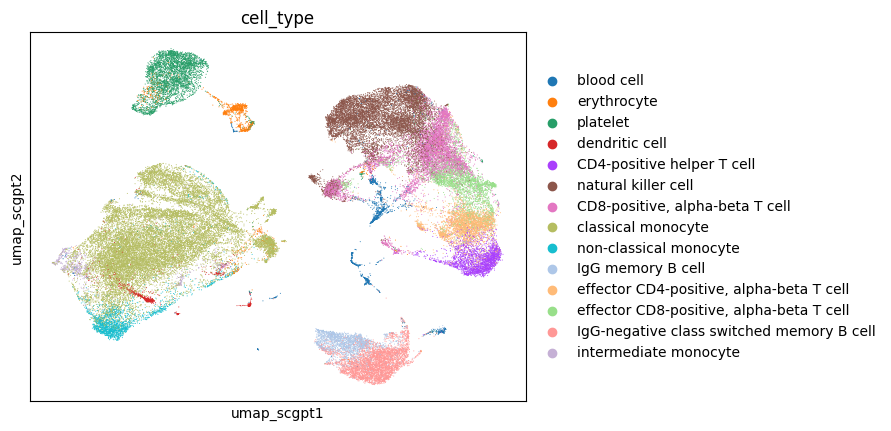

In [151]:
sc.pl.embedding(adata, basis="umap_scgpt", color="cell_type")

In [54]:
import umap
from sklearn.preprocessing import normalize
import scanpy as sc
import pandas as pd

# Add predictions to AnnData
adata.obs["pred_cell_type"] = pd.Categorical([class_names[i] for i in yp])

# Compute UMAP from embeddings (normalize for cosine distance if needed)
Xn = normalize(X_scimmune, norm="l2", axis=1)
um = umap.UMAP(n_neighbors=20, min_dist=0.3, metric="cosine", random_state=0)
adata.obsm["X_umap_scimmune"] = um.fit_transform(Xn)

# Plot true labels
sc.pl.embedding(
    adata,
    basis="X_umap_scimmune",
    color=LABEL_COL,
    title="True Cell Types",
    frameon=False,
    legend_loc='on data'
)

# Plot predicted labels
sc.pl.embedding(
    adata,
    basis="X_umap_scimmune",
    color="pred_cell_type",
    title="Predicted Cell Types",
    frameon=False,
    legend_loc='on data'
)

ValueError: Length of values (11915) does not match length of index (59572)